In [33]:
import inspect
import os

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from helper_functions import *

In [34]:
base_dir = '/home/shiva/Datasets/V2_01_easy/V2_01_easy/Kimera_VIO_Output'
experiment_dir = 'Software_Timestamping_RTOS_IMU'

In [35]:
folders = next(os.walk(f'{base_dir}/{experiment_dir}'))[1]

In [36]:
folders

['IMU_Error_0.0015ms_4Hz_Frame',
 'IMU_Error_0.75ms_4Hz_Frame',
 'IMU_Error_0.5ms_4Hz_Frame',
 'IMU_Error_0.0025ms_4Hz_Frame',
 'IMU_Error_0.001ms_4Hz_Frame',
 'IMU_Error_0.002ms_4Hz_Frame',
 'IMU_Error_0.005ms_6Hz_Frame',
 'IMU_Error_0.5ms_6Hz_Frame',
 'IMU_Error_0.0025ms_6Hz_Frame',
 'IMU_Error_0.0015ms_6Hz_Frame',
 'IMU_Error_1ms_4Hz_Frame',
 'IMU_Error_0.002ms_6Hz_Frame',
 'IMU_Error_0.25ms_6Hz_Frame',
 'IMU_Error_1ms_6Hz_Frame',
 'IMU_Error_0.25ms_4Hz_Frame',
 'IMU_Error_0.001ms_6Hz_Frame',
 'IMU_Error_0.005ms_4Hz_Frame',
 'IMU_Error_0.75ms_6Hz_Frame']

In [37]:
dfs = []
execution_index = 1

for index, execution_folder_name in enumerate(folders):
    df = pd.read_csv(f'{base_dir}/{experiment_dir}/{execution_folder_name}/{execution_index}/traj_vio.csv')
    df['Execution'] = execution_folder_name
    df.rename(columns={'#timestamp': 'timestamp'}, inplace=True)
    dfs.append(df)

In [38]:
gt_df = pd.read_csv(f'{base_dir}/{experiment_dir}/{execution_folder_name}/{execution_index}/traj_gt.csv')
gt_df['Execution'] = 'GT'
gt_df.rename(columns={'#timestamp': 'timestamp'}, inplace=True)
dfs.append(gt_df)

In [39]:
gt_df.shape

(22401, 18)

In [40]:
all_executions = pd.concat(dfs)

In [41]:
all_executions.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 32123 entries, 0 to 22400
Data columns (total 18 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  32123 non-null  int64  
 1   x          32123 non-null  float64
 2   y          32123 non-null  float64
 3   z          32123 non-null  float64
 4   qw         32123 non-null  float64
 5   qx         32123 non-null  float64
 6   qy         32123 non-null  float64
 7   qz         32123 non-null  float64
 8   vx         32123 non-null  float64
 9   vy         32123 non-null  float64
 10  vz         32123 non-null  float64
 11  bgx        32123 non-null  float64
 12  bgy        32123 non-null  float64
 13  bgz        32123 non-null  float64
 14  bax        32123 non-null  float64
 15  bay        32123 non-null  float64
 16  baz        32123 non-null  float64
 17  Execution  32123 non-null  object 
dtypes: float64(16), int64(1), object(1)
memory usage: 4.7+ MB


In [42]:
sns.set_theme(rc={'figure.figsize':(12,6)})

In [43]:
folders

['IMU_Error_0.0015ms_4Hz_Frame',
 'IMU_Error_0.75ms_4Hz_Frame',
 'IMU_Error_0.5ms_4Hz_Frame',
 'IMU_Error_0.0025ms_4Hz_Frame',
 'IMU_Error_0.001ms_4Hz_Frame',
 'IMU_Error_0.002ms_4Hz_Frame',
 'IMU_Error_0.005ms_6Hz_Frame',
 'IMU_Error_0.5ms_6Hz_Frame',
 'IMU_Error_0.0025ms_6Hz_Frame',
 'IMU_Error_0.0015ms_6Hz_Frame',
 'IMU_Error_1ms_4Hz_Frame',
 'IMU_Error_0.002ms_6Hz_Frame',
 'IMU_Error_0.25ms_6Hz_Frame',
 'IMU_Error_1ms_6Hz_Frame',
 'IMU_Error_0.25ms_4Hz_Frame',
 'IMU_Error_0.001ms_6Hz_Frame',
 'IMU_Error_0.005ms_4Hz_Frame',
 'IMU_Error_0.75ms_6Hz_Frame']

In [44]:
import re

def sort_folders_by_number(folder_names):
    def extract_number(folder_name):
        # Use regex to extract the number after 'IMU_Error_'
        match = re.search(r'IMU_Error_([\d.]+)ms', folder_name)
        return float(match.group(1)) if match else float('inf')  # Use infinity if no match
    
    # Sort the list based on the extracted number
    return sorted(folder_names, key=extract_number, reverse=True)

In [45]:
sorted_folders = sort_folders_by_number(folders)
print(sorted_folders)

['IMU_Error_1ms_4Hz_Frame', 'IMU_Error_1ms_6Hz_Frame', 'IMU_Error_0.75ms_4Hz_Frame', 'IMU_Error_0.75ms_6Hz_Frame', 'IMU_Error_0.5ms_4Hz_Frame', 'IMU_Error_0.5ms_6Hz_Frame', 'IMU_Error_0.25ms_6Hz_Frame', 'IMU_Error_0.25ms_4Hz_Frame', 'IMU_Error_0.005ms_6Hz_Frame', 'IMU_Error_0.005ms_4Hz_Frame', 'IMU_Error_0.0025ms_4Hz_Frame', 'IMU_Error_0.0025ms_6Hz_Frame', 'IMU_Error_0.002ms_4Hz_Frame', 'IMU_Error_0.002ms_6Hz_Frame', 'IMU_Error_0.0015ms_4Hz_Frame', 'IMU_Error_0.0015ms_6Hz_Frame', 'IMU_Error_0.001ms_4Hz_Frame', 'IMU_Error_0.001ms_6Hz_Frame']


In [46]:
hue_order = sorted_folders

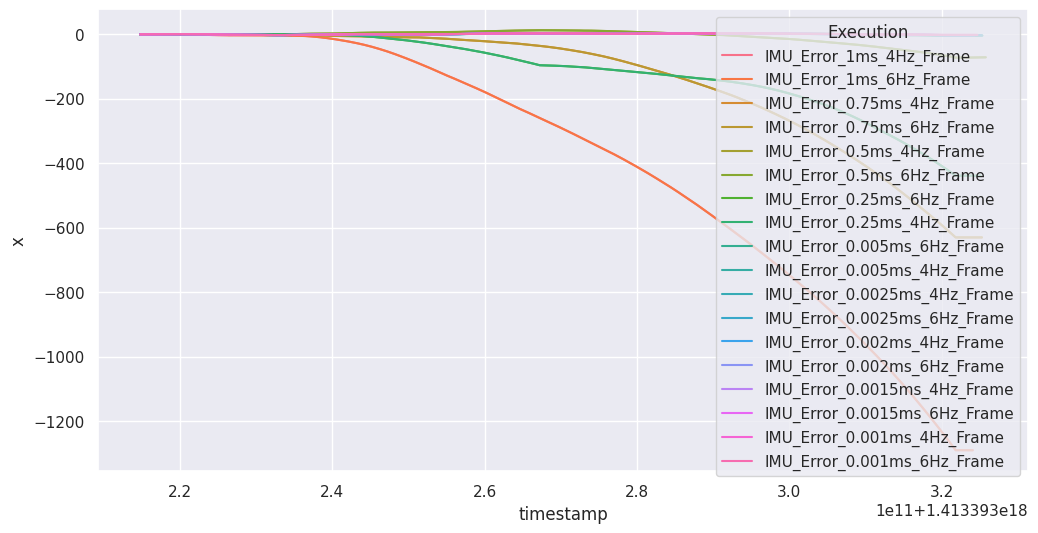

In [47]:
ax = sns.lineplot(data=all_executions, x='timestamp', y='x', hue='Execution', hue_order = hue_order)
# ax.set(ylim=(-4, 4))

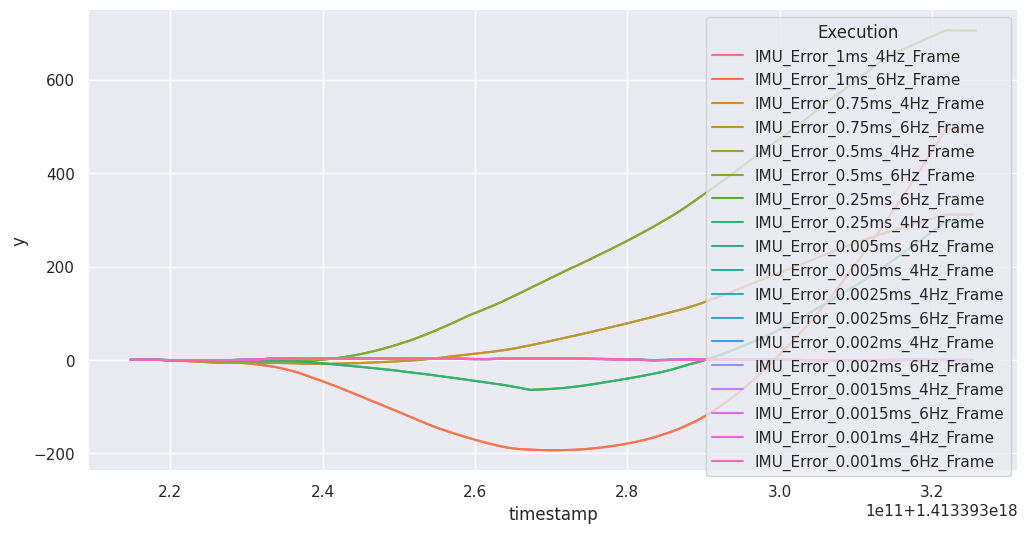

In [48]:
ax = sns.lineplot(data=all_executions, x='timestamp', y='y', hue='Execution', hue_order = hue_order)
# ax.set(ylim=(-4, 4))

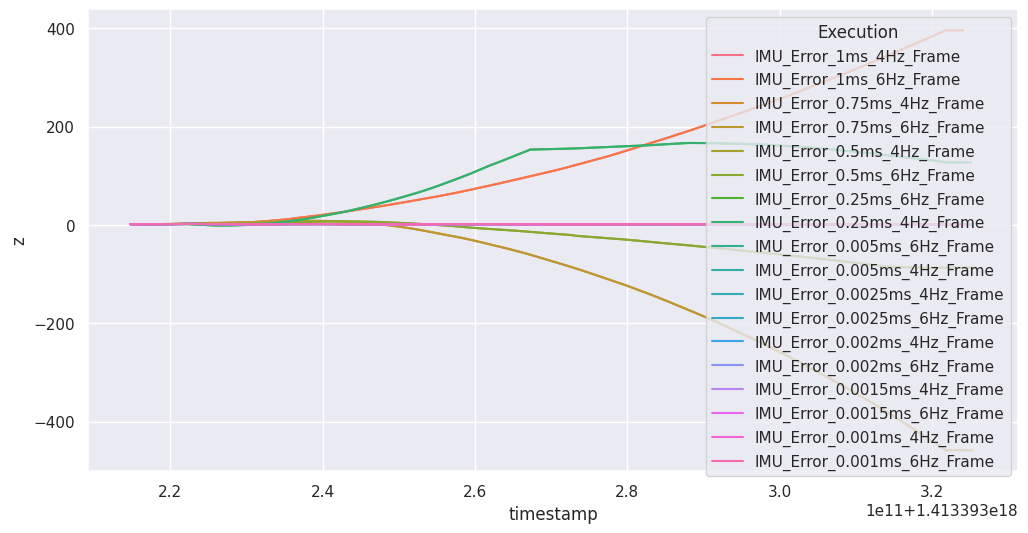

In [49]:
ax = sns.lineplot(data=all_executions, x='timestamp', y='z', hue='Execution', hue_order = hue_order)

In [50]:
np.set_printoptions(precision=20)
pd.set_option('display.float_format', '{:.20f}'.format)

In [51]:
sns.set_theme(rc={'figure.figsize':(12,10)})

values = {}
for df in dfs:
    error_df = generate_error_gt_vio_pose(gt_df, df, DEBUG=False, SHOW_GRAPHS=False)
    values[df.iloc[0]['Execution']] = {'gt_x':error_df.iloc[-1]['gt_pos'][0],
                'gt_y':error_df.iloc[-1]['gt_pos'][1],
                'gt_z':error_df.iloc[-1]['gt_pos'][2],
                'vio_x': error_df.iloc[-1]['vio_pos'][0],
                'vio_y': error_df.iloc[-1]['vio_pos'][1],
                'vio_z': error_df.iloc[-1]['vio_pos'][2],
                'distance': error_df['distance'],
                'error': error_df['error']
                }

# df_comparison = pd.DataFrame(values).T
# df_comparison.reset_index(inplace=True)

# df_comparison_x_axes = pd.melt(df_comparison, id_vars='index', value_vars=['gt_x', 'vio_x'])
# df_comparison_y_axes = pd.melt(df_comparison, id_vars='index', value_vars=['gt_y', 'vio_y'])
# df_comparison_z_axes = pd.melt(df_comparison, id_vars='index', value_vars=['gt_z', 'vio_z'])

540
539
541
exception raised, so breaking out of loop: index 0 is out of bounds for axis 0 with size 0
Empty DataFrame
Columns: [gt_index, distance]
Index: []
540
541
540
540
541
exception raised, so breaking out of loop: index 0 is out of bounds for axis 0 with size 0
Empty DataFrame
Columns: [gt_index, distance]
Index: []
540
540
539
540
541
539
541
541
540
539
22401
exception raised, so breaking out of loop: index 0 is out of bounds for axis 0 with size 0
Empty DataFrame
Columns: [gt_index, distance]
Index: []


In [52]:
values.keys()

dict_keys(['IMU_Error_0.0015ms_4Hz_Frame', 'IMU_Error_0.75ms_4Hz_Frame', 'IMU_Error_0.5ms_4Hz_Frame', 'IMU_Error_0.0025ms_4Hz_Frame', 'IMU_Error_0.001ms_4Hz_Frame', 'IMU_Error_0.002ms_4Hz_Frame', 'IMU_Error_0.005ms_6Hz_Frame', 'IMU_Error_0.5ms_6Hz_Frame', 'IMU_Error_0.0025ms_6Hz_Frame', 'IMU_Error_0.0015ms_6Hz_Frame', 'IMU_Error_1ms_4Hz_Frame', 'IMU_Error_0.002ms_6Hz_Frame', 'IMU_Error_0.25ms_6Hz_Frame', 'IMU_Error_1ms_6Hz_Frame', 'IMU_Error_0.25ms_4Hz_Frame', 'IMU_Error_0.001ms_6Hz_Frame', 'IMU_Error_0.005ms_4Hz_Frame', 'IMU_Error_0.75ms_6Hz_Frame', 'GT'])

In [53]:
error_distance_dfs = []

for i in values.keys():
    err_df = pd.DataFrame(data={'Distance (m)': values[i]['distance'], 'Error (m)':values[i]['error'], 'Execution':i})
    error_distance_dfs.append(err_df)

error_distance_dfs = pd.concat(error_distance_dfs)

In [54]:
res = []

for exec_no, data in error_distance_dfs.groupby('Execution'):
    print(exec_no)
    res.append(data.iloc[-1])

GT
IMU_Error_0.0015ms_4Hz_Frame
IMU_Error_0.0015ms_6Hz_Frame
IMU_Error_0.001ms_4Hz_Frame
IMU_Error_0.001ms_6Hz_Frame
IMU_Error_0.0025ms_4Hz_Frame
IMU_Error_0.0025ms_6Hz_Frame
IMU_Error_0.002ms_4Hz_Frame
IMU_Error_0.002ms_6Hz_Frame
IMU_Error_0.005ms_4Hz_Frame
IMU_Error_0.005ms_6Hz_Frame
IMU_Error_0.25ms_4Hz_Frame
IMU_Error_0.25ms_6Hz_Frame
IMU_Error_0.5ms_4Hz_Frame
IMU_Error_0.5ms_6Hz_Frame
IMU_Error_0.75ms_4Hz_Frame
IMU_Error_0.75ms_6Hz_Frame
IMU_Error_1ms_4Hz_Frame
IMU_Error_1ms_6Hz_Frame


In [55]:
res = pd.DataFrame(res)

In [56]:
error_distance_dfs['Execution'].unique()

array(['IMU_Error_0.0015ms_4Hz_Frame', 'IMU_Error_0.75ms_4Hz_Frame',
       'IMU_Error_0.5ms_4Hz_Frame', 'IMU_Error_0.0025ms_4Hz_Frame',
       'IMU_Error_0.001ms_4Hz_Frame', 'IMU_Error_0.002ms_4Hz_Frame',
       'IMU_Error_0.005ms_6Hz_Frame', 'IMU_Error_0.5ms_6Hz_Frame',
       'IMU_Error_0.0025ms_6Hz_Frame', 'IMU_Error_0.0015ms_6Hz_Frame',
       'IMU_Error_1ms_4Hz_Frame', 'IMU_Error_0.002ms_6Hz_Frame',
       'IMU_Error_0.25ms_6Hz_Frame', 'IMU_Error_1ms_6Hz_Frame',
       'IMU_Error_0.25ms_4Hz_Frame', 'IMU_Error_0.001ms_6Hz_Frame',
       'IMU_Error_0.005ms_4Hz_Frame', 'IMU_Error_0.75ms_6Hz_Frame', 'GT'],
      dtype=object)

Text(0.5, 1.0, 'Error as Distance Increases - Baseline Experiments')

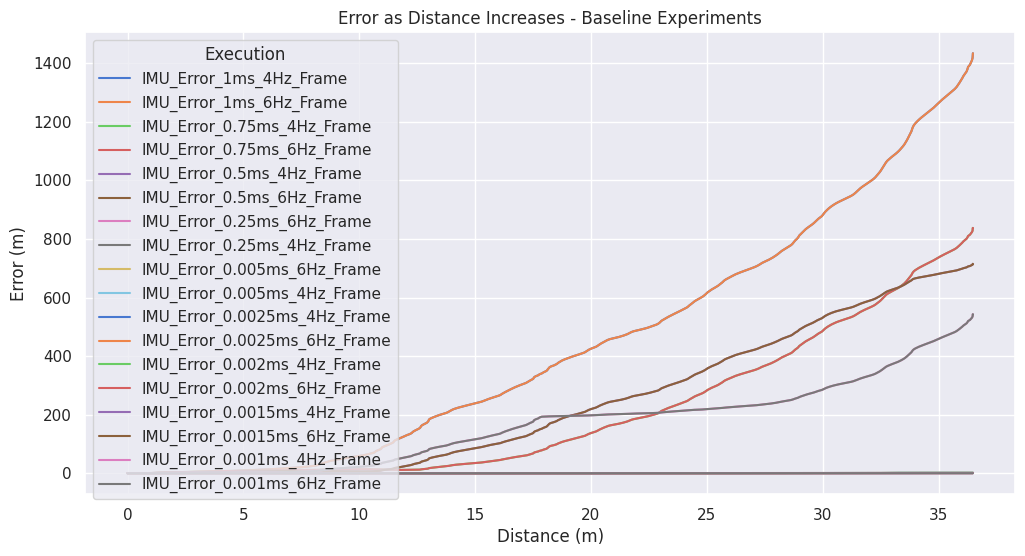

In [57]:
sns.set_theme(rc={'figure.figsize':(12, 6)})

title = 'Error as Distance Increases - Baseline Experiments'

g = sns.lineplot(data = error_distance_dfs, x='Distance (m)', y = 'Error (m)', hue='Execution', legend='full', palette='muted', hue_order = hue_order)
g.set_title(title)

In [58]:
sorted_folders

['IMU_Error_1ms_4Hz_Frame',
 'IMU_Error_1ms_6Hz_Frame',
 'IMU_Error_0.75ms_4Hz_Frame',
 'IMU_Error_0.75ms_6Hz_Frame',
 'IMU_Error_0.5ms_4Hz_Frame',
 'IMU_Error_0.5ms_6Hz_Frame',
 'IMU_Error_0.25ms_6Hz_Frame',
 'IMU_Error_0.25ms_4Hz_Frame',
 'IMU_Error_0.005ms_6Hz_Frame',
 'IMU_Error_0.005ms_4Hz_Frame',
 'IMU_Error_0.0025ms_4Hz_Frame',
 'IMU_Error_0.0025ms_6Hz_Frame',
 'IMU_Error_0.002ms_4Hz_Frame',
 'IMU_Error_0.002ms_6Hz_Frame',
 'IMU_Error_0.0015ms_4Hz_Frame',
 'IMU_Error_0.0015ms_6Hz_Frame',
 'IMU_Error_0.001ms_4Hz_Frame',
 'IMU_Error_0.001ms_6Hz_Frame']

In [59]:
sorted_folders[8:]

['IMU_Error_0.005ms_6Hz_Frame',
 'IMU_Error_0.005ms_4Hz_Frame',
 'IMU_Error_0.0025ms_4Hz_Frame',
 'IMU_Error_0.0025ms_6Hz_Frame',
 'IMU_Error_0.002ms_4Hz_Frame',
 'IMU_Error_0.002ms_6Hz_Frame',
 'IMU_Error_0.0015ms_4Hz_Frame',
 'IMU_Error_0.0015ms_6Hz_Frame',
 'IMU_Error_0.001ms_4Hz_Frame',
 'IMU_Error_0.001ms_6Hz_Frame']

In [60]:
filtered_folders = sorted_folders[8:]

In [61]:
error_distance_dfs_filtered = error_distance_dfs[error_distance_dfs['Execution'].isin(filtered_folders)]

In [62]:
error_distance_dfs_filtered

,Distance (m),Error (m),Execution
0,0.00000000000000000000,0.00005741950887992281,IMU_Error_0.0015ms_4Hz_Frame
1,0.00133344913806076747,0.00063409435368728408,IMU_Error_0.0015ms_4Hz_Frame
2,0.00468585063132989643,0.00108964739607157767,IMU_Error_0.0015ms_4Hz_Frame
3,0.00630611185037854155,0.00154447608240693601,IMU_Error_0.0015ms_4Hz_Frame
4,0.00829811942856870273,0.00261897172076817550,IMU_Error_0.0015ms_4Hz_Frame
...,...,...,...
535,36.47828848203026552710,2.09836088238421369923,IMU_Error_0.005ms_4Hz_Frame
536,36.47888562405816514911,2.09751229281939677307,IMU_Error_0.005ms_4Hz_Frame
537,36.48213942730162528960,2.08541586684454216538,IMU_Error_0.005ms_4Hz_Frame
538,36.48293430201952247671,2.08536875029741874954,IMU_Error_0.005ms_4Hz_Frame


Text(0.5, 1.0, 'Error as Distance Increases - Experiments with us Error Added')

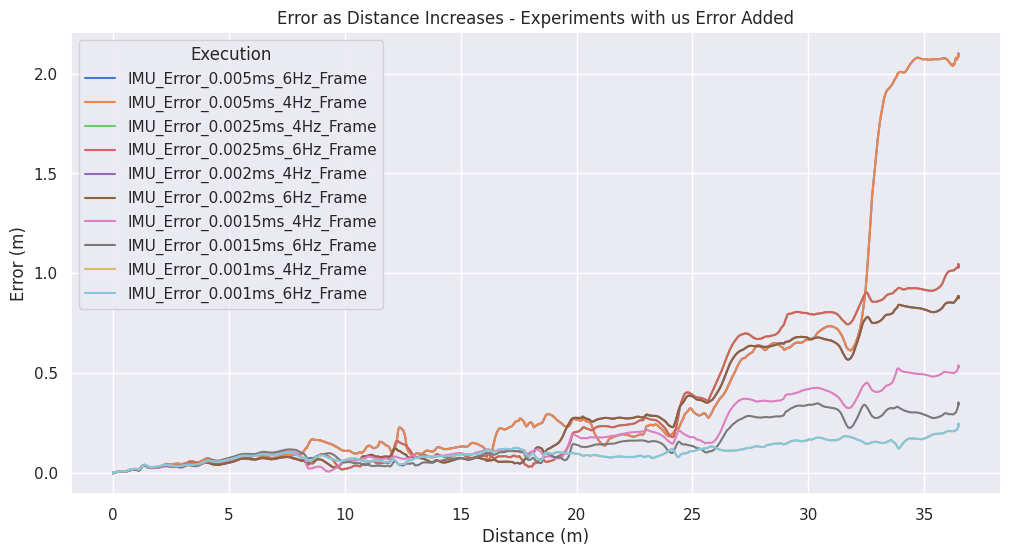

In [63]:
sns.set_theme(rc={'figure.figsize':(12, 6)})

title = 'Error as Distance Increases - Experiments with us Error Added'

g = sns.lineplot(data = error_distance_dfs_filtered, x='Distance (m)', y = 'Error (m)', hue='Execution', legend='full', palette='muted', hue_order = filtered_folders)
g.set_title(title)